# Part 0 - Loads and Helper Functions

In [1]:
# ==================================================
# GENERAL
# ==================================================

import numpy as np
import pandas as pd

# ==================================================
# VISUALIZATION
# ==================================================

import matplotlib.pyplot as plt

# ==================================================
# SKLEARN
# ==================================================

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ndcg_score

# ==================================================
# SURPRISE (SVD)
# ==================================================

from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise import accuracy

# ==================================================
# WARNINGS
# ==================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from datetime import datetime

## Global Configurations

In [2]:
# Reproducibility
SEED = 42

# Paths
TRAIN_PATH = "../data/training_set_VU_DM.csv"
TEST_PATH = "../data/test_set_VU_DM.csv"

# Target engineering
BOOKING_RELEVANCE = 5
CLICK_RELEVANCE = 1
TARGET_COL = "target"

# Validation split
TEST_SIZE = 0.2

# Ranking evaluation
NDCG_AT = 5


# Columns to remove from features
LEAKAGE_COLS = [
    "target",
    "booking_bool",
    "click_bool",
    "gross_bookings_usd",
    "position",
]

ID_COLS = [
    "srch_id",
    "site_id",
    "visitor_location_country_id",
    "prop_country_id",
    "prop_id",
    "srch_destination_id",
]

DATE_COLS = [
    "date_time",
    "date",
]

SCALE_COLS = [

    "price_usd_log",
    "srch_booking_window_log",
    "prop_location_score2_log",
    "orig_destination_distance_log",
    "visitor_hist_adr_usd_log",

    "prop_review_score",
    "srch_query_affinity_score",
    "visitor_hist_starrating"

]

DROP_COLS = LEAKAGE_COLS + ID_COLS + DATE_COLS

## Defining Columns and Data Types

In [3]:
cont_cols = [
    'visitor_hist_starrating',
    'visitor_hist_adr_usd',
    'prop_review_score',
    'prop_location_score1',
    'prop_location_score2',
    'prop_log_historical_price',
    'price_usd',
    'srch_query_affinity_score',
    'orig_destination_distance',
    'gross_bookings_usd',
    'comp1_rate_percent_diff',
    'comp2_rate_percent_diff',
    'comp3_rate_percent_diff',
    'comp4_rate_percent_diff',
    'comp5_rate_percent_diff',
    'comp6_rate_percent_diff',
    'comp7_rate_percent_diff',
    'comp8_rate_percent_diff'
]

bool_cols = [
    'prop_brand_bool',
    'promotion_flag',
    'srch_saturday_night_bool',
    'random_bool',
    'click_bool',
    'booking_bool'
]

id_cols = [
    'srch_id',
    'site_id',
    'visitor_location_country_id',
    'prop_country_id',
    'prop_id',
    'srch_destination_id'
]

cat_cols = [
    'comp1_rate', 'comp1_inv',
    'comp2_rate', 'comp2_inv',
    'comp3_rate', 'comp3_inv',
    'comp4_rate', 'comp4_inv',
    'comp5_rate', 'comp5_inv',
    'comp6_rate', 'comp6_inv',
    'comp7_rate', 'comp7_inv',
    'comp8_rate', 'comp8_inv'
]

int_cols = [
    'prop_starrating',
    'position',
    'srch_length_of_stay',
    'srch_booking_window',
    'srch_adults_count',
    'srch_children_count',
    'srch_room_count'
]

In [4]:
dtype_dict = {}

# float columns
for col in cont_cols:
    dtype_dict[col] = 'float32'

# bool columns
for col in bool_cols:
    dtype_dict[col] = 'bool'

# id columns
for col in id_cols:
    dtype_dict[col] = 'Int32'

# categorical columns
for col in cat_cols:
    dtype_dict[col] = 'Int16'

# small integer columns
for col in int_cols:
    dtype_dict[col] = 'Int8'

## Helper Functions

### Loading

In [5]:
# Load Training Data
def load_train_data(
    path,
    booking_relevance=5,
    click_relevance=1
):

    df = pd.read_csv(
        path,
        dtype=dtype_dict,
        low_memory=True
    )

    # Create Target
    df["target"] = (
        booking_relevance * df["booking_bool"].astype("int8") +
        click_relevance * df["click_bool"].astype("int8")
    ).astype("int8")

    return df

In [6]:
# Load Testing Data
def load_test_data(path):

    df = pd.read_csv(
        path,
        dtype=dtype_dict,
        low_memory=True
    )

    return df

### Preprocessing

In [7]:
# Stateless Prepocess Function (applied before Train-Val split)
def stateless_preprocess(
    df,
    comp_rate_diff_upper_limit=150
):

    df = df.copy()

    # ==================================================
    # DATE PARSING
    # ==================================================

    df["date_time"] = pd.to_datetime(df["date_time"])

    # ==================================================
    # WRONG VALUE HANDLING
    # ==================================================

    # Negative booking windows are invalid
    df["srch_booking_window"] = (
        df["srch_booking_window"]
        .clip(lower=0)
    )

    # ==================================================
    # OUTLIER CAPPING
    # ==================================================

    # Cap extreme competitor rate differences
    for i in range(1, 9):

        col = f"comp{i}_rate_percent_diff"

        df[col] = (
            df[col]
            .clip(upper=comp_rate_diff_upper_limit)
        )

    # ==================================================
    # SEMANTIC MISSING VALUES -> NaN
    # ==================================================

    # Unknown starrating
    df["prop_starrating"] = (
        df["prop_starrating"]
        .replace(0, np.nan)
    )

    # Unknown historical price
    df["prop_log_historical_price"] = (
        df["prop_log_historical_price"]
        .replace(0, np.nan)
    )

    # Unknown review score
    df["prop_review_score"] = (
        df["prop_review_score"]
        .replace(0, np.nan)
    )


    return df

In [8]:
# ==================================================
# FIT LEARNED PREPROCESSING (SVD VERSION)
# ==================================================
def fit_learned_preprocessing(
    train_df,
    price_usd_quantile=0.995,
    booking_window_quantile=0.995,
    comp_rate_diff_upper_limit=150
):

    stats = {}

    # ==================================================
    # OUTLIER CAPS
    # ==================================================

    stats["price_usd_upper_cap"] = (
        train_df["price_usd"]
        .quantile(price_usd_quantile)
    )

    stats["srch_booking_window_upper_cap"] = (
        train_df["srch_booking_window"]
        .quantile(booking_window_quantile)
    )

    stats["comp_rate_diff_upper_cap"] = (
        comp_rate_diff_upper_limit
    )

    # ==================================================
    # GLOBAL IMPUTATION VALUES
    # ==================================================

    stats["prop_starrating_mode"] = (
        train_df["prop_starrating"]
        .mode()[0]
    )

    stats["prop_log_historical_price_median"] = (
        train_df["prop_log_historical_price"]
        .median()
    )

    stats["prop_review_score_median"] = (
        train_df["prop_review_score"]
        .median()
    )

    stats["prop_location_score2_median"] = (
        train_df["prop_location_score2"]
        .median()
    )

    stats["orig_destination_distance_median"] = (
        train_df["orig_destination_distance"]
        .median()
    )

    stats["srch_query_affinity_score_median"] = (
        train_df["srch_query_affinity_score"]
        .median()
    )

    stats["visitor_hist_starrating_median"] = (
        train_df["visitor_hist_starrating"]
        .median()
    )

    stats["visitor_hist_adr_usd_median"] = (
        train_df["visitor_hist_adr_usd"]
        .median()
    )

    # ==================================================
    # COMPETITOR FEATURES
    # ==================================================

    for i in range(1, 9):

        col = f"comp{i}_rate_percent_diff"

        stats[f"{col}_median"] = (
            train_df[col]
            .median()
        )

    return stats

In [9]:
# ==================================================
# APPLY LEARNED PREPROCESSING (SVD VERSION)
# ==================================================
def apply_learned_preprocessing(
    df,
    stats
):

    df = df.copy()

    # ==================================================
    # PRICE USD
    # ==================================================

    df["price_usd"] = (
        df["price_usd"]
        .clip(upper=stats["price_usd_upper_cap"])
        .astype("float32")
    )

    df["price_usd_log"] = (
        np.log1p(df["price_usd"])
        .astype("float32")
    )

    # ==================================================
    # SEARCH BOOKING WINDOW
    # ==================================================

    df["srch_booking_window"] = (
        df["srch_booking_window"]
        .clip(
            upper=stats["srch_booking_window_upper_cap"]
        )
        .astype("float32")
    )

    df["srch_booking_window_log"] = (
        np.log1p(df["srch_booking_window"])
        .astype("float32")
    )

    # ==================================================
    # PROPERTY FEATURES
    # ==================================================

    df["prop_starrating"] = (
        df["prop_starrating"]
        .fillna(stats["prop_starrating_mode"])
        .astype("float32")
    )

    df["prop_log_historical_price"] = (
        df["prop_log_historical_price"]
        .fillna(
            stats["prop_log_historical_price_median"]
        )
        .astype("float32")
    )

    df["prop_review_score"] = (
        df["prop_review_score"]
        .fillna(stats["prop_review_score_median"])
        .astype("float32")
    )

    df["prop_location_score2"] = (
        df["prop_location_score2"]
        .fillna(stats["prop_location_score2_median"])
        .astype("float32")
    )

    df["prop_location_score2_log"] = (
        np.log1p(df["prop_location_score2"])
        .astype("float32")
    )

    # ==================================================
    # DESTINATION DISTANCE
    # ==================================================

    df["orig_destination_distance"] = (
        df["orig_destination_distance"]
        .fillna(
            stats["orig_destination_distance_median"]
        )
        .astype("float32")
    )

    df["orig_destination_distance_log"] = (
        np.log1p(df["orig_destination_distance"])
        .astype("float32")
    )

    # ==================================================
    # SEARCH QUERY AFFINITY
    # ==================================================

    df["srch_query_affinity_score"] = (
        df["srch_query_affinity_score"]
        .fillna(
            stats["srch_query_affinity_score_median"]
        )
        .astype("float32")
    )

    # ==================================================
    # VISITOR HISTORY FEATURES
    # ==================================================

    df["visitor_hist_starrating"] = (
        df["visitor_hist_starrating"]
        .fillna(
            stats["visitor_hist_starrating_median"]
        )
        .astype("float32")
    )

    df["visitor_hist_adr_usd"] = (
        df["visitor_hist_adr_usd"]
        .fillna(
            stats["visitor_hist_adr_usd_median"]
        )
        .astype("float32")
    )

    df["visitor_hist_adr_usd_log"] = (
        np.log1p(df["visitor_hist_adr_usd"])
        .astype("float32")
    )

    # ==================================================
    # COMPETITOR FEATURES
    # ==================================================

    for i in range(1, 9):

        col = f"comp{i}_rate_percent_diff"

        df[col] = (
            df[col]
            .clip(
                upper=stats["comp_rate_diff_upper_cap"]
            )
            .fillna(stats[f"{col}_median"])
            .astype("float32")
        )

        df[f"{col}_log"] = (
            np.log1p(df[col])
            .astype("float32")
        )

    return df

In [10]:
# ==================================================
# FIT SCALER
# ==================================================

def fit_scaler(
    train_df,
    scale_cols
):

    scaler = StandardScaler()

    scaler.fit(
        train_df[scale_cols]
    )

    return scaler

In [11]:
# ==================================================
# APPLY SCALER
# ==================================================

def apply_scaler(
    df,
    scaler,
    scale_cols
):

    df = df.copy()

    df[scale_cols] = scaler.transform(
        df[scale_cols]
    )

    return df

### Train-Validation Split

In [12]:
# Train-Val Split Function
def train_val_split(
    df,
    group_col="srch_id",
    test_size=0.2,
    random_state=42
):

    df = df.reset_index(drop=True)

    splitter = GroupShuffleSplit(
        test_size=test_size,
        n_splits=1,
        random_state=random_state
    )

    train_idx, val_idx = next(
        splitter.split(
            df,
            groups=df[group_col]
        )
    )

    train_df = df.iloc[train_idx].copy()
    val_df = df.iloc[val_idx].copy()

    assert (
        len(train_df) + len(val_df)
        == len(df)
    )

    return train_df, val_df

### Modeling

In [13]:
# ==================================================
# CREATE INTERACTION MATRIX
# ==================================================
def create_interaction_matrix(
    df,
    user_col="srch_id",
    item_col="prop_id",
    target_col="target"
):

    interaction_df = df[[

        user_col,
        item_col,
        target_col

    ]].copy()

    interaction_df.columns = [

        "user",
        "item",
        "rating"

    ]

    return interaction_df

### Training

### Evaluation

In [14]:
# ==================================================
# NDCG@5 FUNCTION
# ==================================================
def compute_ndcg_at_k(
    pred_df,
    k=5
):

    ndcg_scores = []

    # ==================================================
    # GROUP BY SEARCH
    # ==================================================

    for _, group in pred_df.groupby("srch_id"):

        # Skip groups with no relevance
        if group["true_relevance"].sum() == 0:
            continue

        # ==================================================
        # TRUE + PREDICTED SCORES
        # ==================================================

        y_true = (
            group["true_relevance"]
            .to_numpy()
            .reshape(1, -1)
        )

        y_score = (
            group["pred_score"]
            .to_numpy()
            .reshape(1, -1)
        )

        # ==================================================
        # COMPUTE NDCG
        # ==================================================

        ndcg = ndcg_score(
            y_true,
            y_score,
            k=k
        )

        ndcg_scores.append(ndcg)

    # ==================================================
    # FINAL MEAN SCORE
    # ==================================================

    return np.mean(ndcg_scores)

In [15]:
# =========================================================
# TOP-K BOOKING / CLICK RETRIEVAL EVALUATION (SVD)
# =========================================================

# =========================================================
# TOP-K BOOKING / CLICK RETRIEVAL EVALUATION (SVD)
# =========================================================

def evaluate_topk_behavior(
    pred_df,
    val_df,
    max_k=5
):

    # =====================================================
    # MERGE BACK CLICK + BOOKING LABELS
    # =====================================================

    eval_df = pred_df.merge(

        val_df[[
            "srch_id",
            "prop_id",
            "click_bool",
            "booking_bool"
        ]],

        on=["srch_id", "prop_id"],
        how="left"

    )

    # =====================================================
    # SORT BY PREDICTED SCORE
    # =====================================================

    eval_df = (
        eval_df
        .sort_values(
            ["srch_id", "pred_score"],
            ascending=[True, False]
        )
    )

    # =====================================================
    # RANK WITHIN SEARCH
    # =====================================================

    eval_df["pred_rank"] = (

        eval_df
        .groupby("srch_id")
        .cumcount() + 1

    )

    # =====================================================
    # BOOKING SEARCHES
    # =====================================================

    booking_searches = (

        eval_df
        .groupby("srch_id")["booking_bool"]
        .sum()

    )

    booking_search_ids = (

        booking_searches[
            booking_searches > 0
        ].index

    )

    booking_df = (

        eval_df[
            eval_df["srch_id"]
            .isin(booking_search_ids)
        ]

    )

    booking_topk = []

    for k in range(1, max_k + 1):

        topk_df = (

            booking_df[
                booking_df["pred_rank"] <= k
            ]

        )

        success = (

            topk_df
            .groupby("srch_id")["booking_bool"]
            .max()
            .mean()

        )

        booking_topk.append(success * 100)

    # =====================================================
    # CLICK-ONLY SEARCHES
    # =====================================================

    search_booking = (

        eval_df
        .groupby("srch_id")["booking_bool"]
        .sum()

    )

    click_search_ids = (

        search_booking[
            search_booking == 0
        ].index

    )

    click_df = (

        eval_df[
            eval_df["srch_id"]
            .isin(click_search_ids)
        ]

    )

    click_topk = []

    for k in range(1, max_k + 1):

        topk_df = (

            click_df[
                click_df["pred_rank"] <= k
            ]

        )

        success = (

            topk_df
            .groupby("srch_id")["click_bool"]
            .max()
            .mean()

        )

        click_topk.append(success * 100)

    # =====================================================
    # PLOTS
    # =====================================================

    ks = np.arange(1, max_k + 1)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 5)
    )

    # =====================================================
    # BOOKING PLOT
    # =====================================================

    bars1 = axes[0].bar(
        ks,
        booking_topk
    )

    axes[0].set_title(
        "Booked Hotel Retrieved in Top-K"
    )

    axes[0].set_xlabel("K")
    axes[0].set_ylabel("Probability (%)")
    axes[0].set_xticks(ks)

    # Add booking labels
    for bar, value in zip(bars1, booking_topk):

        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{value:.2f}%",
            ha="center",
            va="bottom"
        )

    # =====================================================
    # CLICK PLOT
    # =====================================================

    bars2 = axes[1].bar(
        ks,
        click_topk
    )

    axes[1].set_title(
        "Clicked Hotel Retrieved in Top-K\n(No Booking Searches)"
    )

    axes[1].set_xlabel("K")
    axes[1].set_ylabel("Probability (%)")
    axes[1].set_xticks(ks)

    # Add click labels
    for bar, value in zip(bars2, click_topk):

        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{value:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

## Load Datasets

In [16]:
#  ========== Load Training Data ==========
train_df = load_train_data(
    TRAIN_PATH,
    booking_relevance=5,
    click_relevance=2
)
print(f"Shape of training set: {train_df.shape}")
train_df.dtypes

Shape of training set: (4958347, 55)


srch_id                          Int32
date_time                       object
site_id                          Int32
visitor_location_country_id      Int32
visitor_hist_starrating        float32
visitor_hist_adr_usd           float32
prop_country_id                  Int32
prop_id                          Int32
prop_starrating                   Int8
prop_review_score              float32
prop_brand_bool                   bool
prop_location_score1           float32
prop_location_score2           float32
prop_log_historical_price      float32
position                          Int8
price_usd                      float32
promotion_flag                    bool
srch_destination_id              Int32
srch_length_of_stay               Int8
srch_booking_window               Int8
srch_adults_count                 Int8
srch_children_count               Int8
srch_room_count                   Int8
srch_saturday_night_bool          bool
srch_query_affinity_score      float32
orig_destination_distance

# Part 1 - Preprocessing for Train, Validation, Test Sets

In [17]:
# ==================================================
# STATELESS PREPROCESSING
# ==================================================

train_df = stateless_preprocess(train_df)

print("AFTER STATELESS PROCESSING")
print(train_df.shape)

# ==================================================
# TRAIN / VALIDATION SPLIT
# ==================================================

train_df, val_df = train_val_split(
    train_df,
    group_col="srch_id",
    test_size=TEST_SIZE,
    random_state=SEED
)

print("AFTER SPLITTING")
print(train_df.shape)
print(val_df.shape)

# ==================================================
# FIT LEARNED PREPROCESSING
# ==================================================

preprocessing_stats = fit_learned_preprocessing(
    train_df,
    price_usd_quantile=0.995
)

# ==================================================
# APPLY LEARNED PREPROCESSING
# ==================================================

train_df = apply_learned_preprocessing(
    train_df,
    preprocessing_stats
)

val_df = apply_learned_preprocessing(
    val_df,
    preprocessing_stats
)

print("BEFORE SCALING")
print(train_df.shape)
print(val_df.shape)

# ==================================================
# SCALING
# ==================================================

scaler = fit_scaler(
    train_df,
    SCALE_COLS
)

train_df = apply_scaler(
    train_df,
    scaler,
    SCALE_COLS
)

val_df = apply_scaler(
    val_df,
    scaler,
    SCALE_COLS
)

AFTER STATELESS PROCESSING
(4958347, 55)
AFTER SPLITTING
(3966682, 55)
(991665, 55)
BEFORE SCALING
(3966682, 68)
(991665, 68)


In [18]:
print(train_df.shape)
print(val_df.shape)

(3966682, 68)
(991665, 68)


In [19]:
# ==================================================
# CREATE INTERACTION MATRICES
# ==================================================

train_interactions = create_interaction_matrix(
    train_df
)

val_interactions = create_interaction_matrix(
    val_df
)

### Verifying Preprocessing

In [20]:
# ==================================================
# VERIFY SHAPES
# ==================================================

print("========== SHAPES ==========")

print(f"Train shape:      {train_interactions.shape}")
print(f"Validation shape: {val_interactions.shape}")

train_interactions.head()

========== SHAPES ==========
Train shape:      (3966682, 3)
Validation shape: (991665, 3)


,user,item,rating
0,1,893,0
1,1,10404,0
2,1,21315,0
3,1,27348,0
4,1,29604,0


# Part 2 - Modeling

### 2.1 Preparation

In [21]:
# ==================================================
# BUILD SURPRISE DATASETS
# ==================================================

reader = Reader(
    rating_scale=(0, 6)
)

train_data = Dataset.load_from_df(
    train_interactions[
        ["user", "item", "rating"]
    ],
    reader
)

val_data = Dataset.load_from_df(
    val_interactions[
        ["user", "item", "rating"]
    ],
    reader
)

trainset = train_data.build_full_trainset()

valset = val_data.build_full_trainset().build_testset()

### 2.2 Training

In [22]:
# ==================================================
# TRAIN SVD MODEL
# ==================================================

svd_model = SVD(

    n_factors=100,
    n_epochs=20,

    lr_all=0.005,
    reg_all=0.02,

    random_state=SEED,
    verbose=True
)

svd_model.fit(trainset)

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19


### 2.3 Evaluation

In [23]:
# ==================================================
# VALIDATION PREDICTIONS
# ==================================================

predictions = svd_model.test(valset)

# ==================================================
# EVALUATION
# ==================================================

rmse = accuracy.rmse(
    predictions,
    verbose=True
)

mae = accuracy.mae(
    predictions,
    verbose=True
)

# ==================================================
# CONVERT PREDICTIONS TO DATAFRAME
# ==================================================

pred_df = pd.DataFrame([

    {
        "srch_id": int(pred.uid),
        "prop_id": int(pred.iid),

        "true_relevance": pred.r_ui,
        "pred_score": pred.est
    }

    for pred in predictions

])

RMSE: 1.1666
MAE:  0.4476


In [24]:
# ==================================================
# COMPUTE NDCG@5
# ==================================================

svd_ndcg5 = compute_ndcg_at_k(
    pred_df,
    k=5
)

print(f"SVD NDCG@5: {svd_ndcg5:.5f}")

SVD NDCG@5: 0.28218


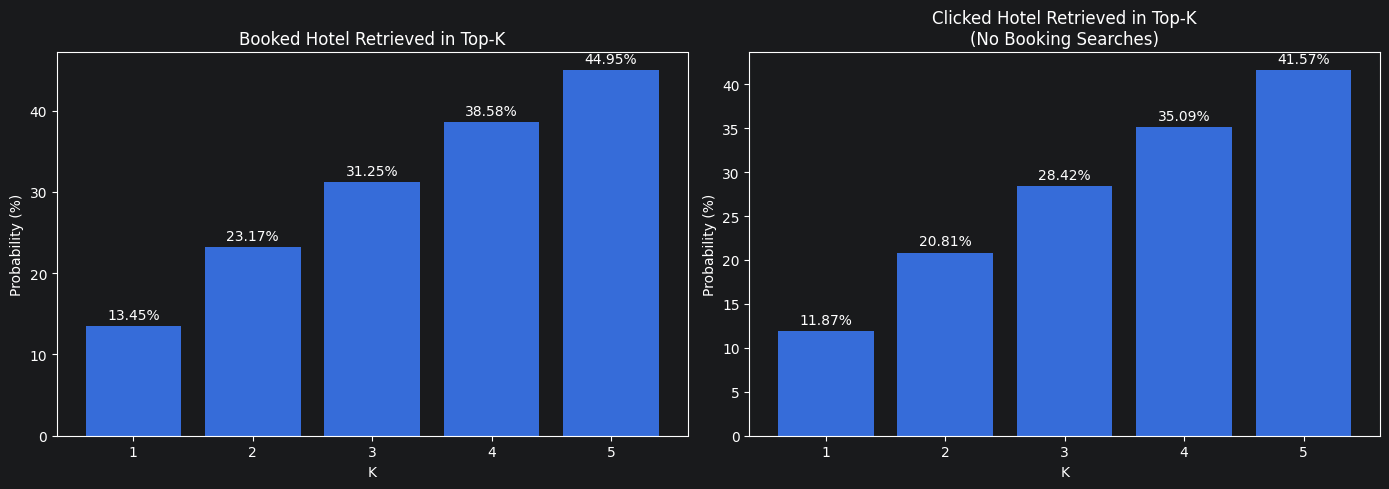

In [25]:
# =========================================================
# EVALUATION of TopK Behavior
# =========================================================
evaluate_topk_behavior(
    pred_df=pred_df,
    val_df=val_df,
    max_k=5
)